In [1]:
# Importing necessary library
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.neural_network import MLPClassifier # MLPClassifier - for classification
from sklearn.metrics import f1_score

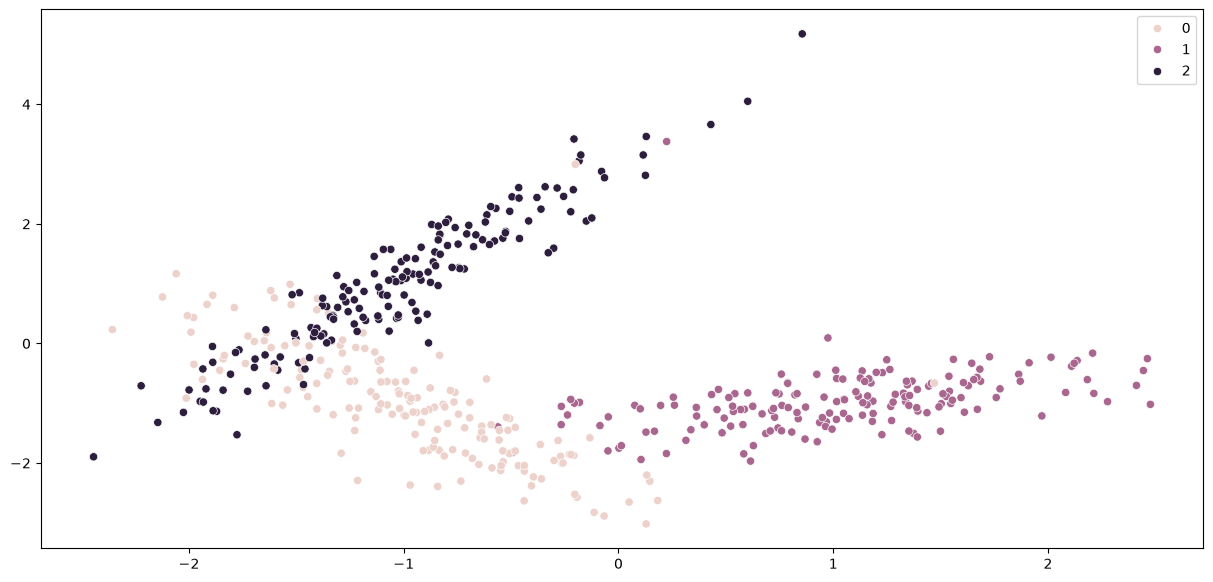

In [2]:
# Creating Dummy Dataset
X, y = make_classification(
    n_samples = 500,
    n_features = 2,
    n_informative = 2,
    n_redundant = 0,
    n_classes = 3,
    n_clusters_per_class = 1,
    class_sep = 1,
    random_state = 5
)

plt.figure(figsize=(15, 7))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.show()

In [3]:
# Train Test Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

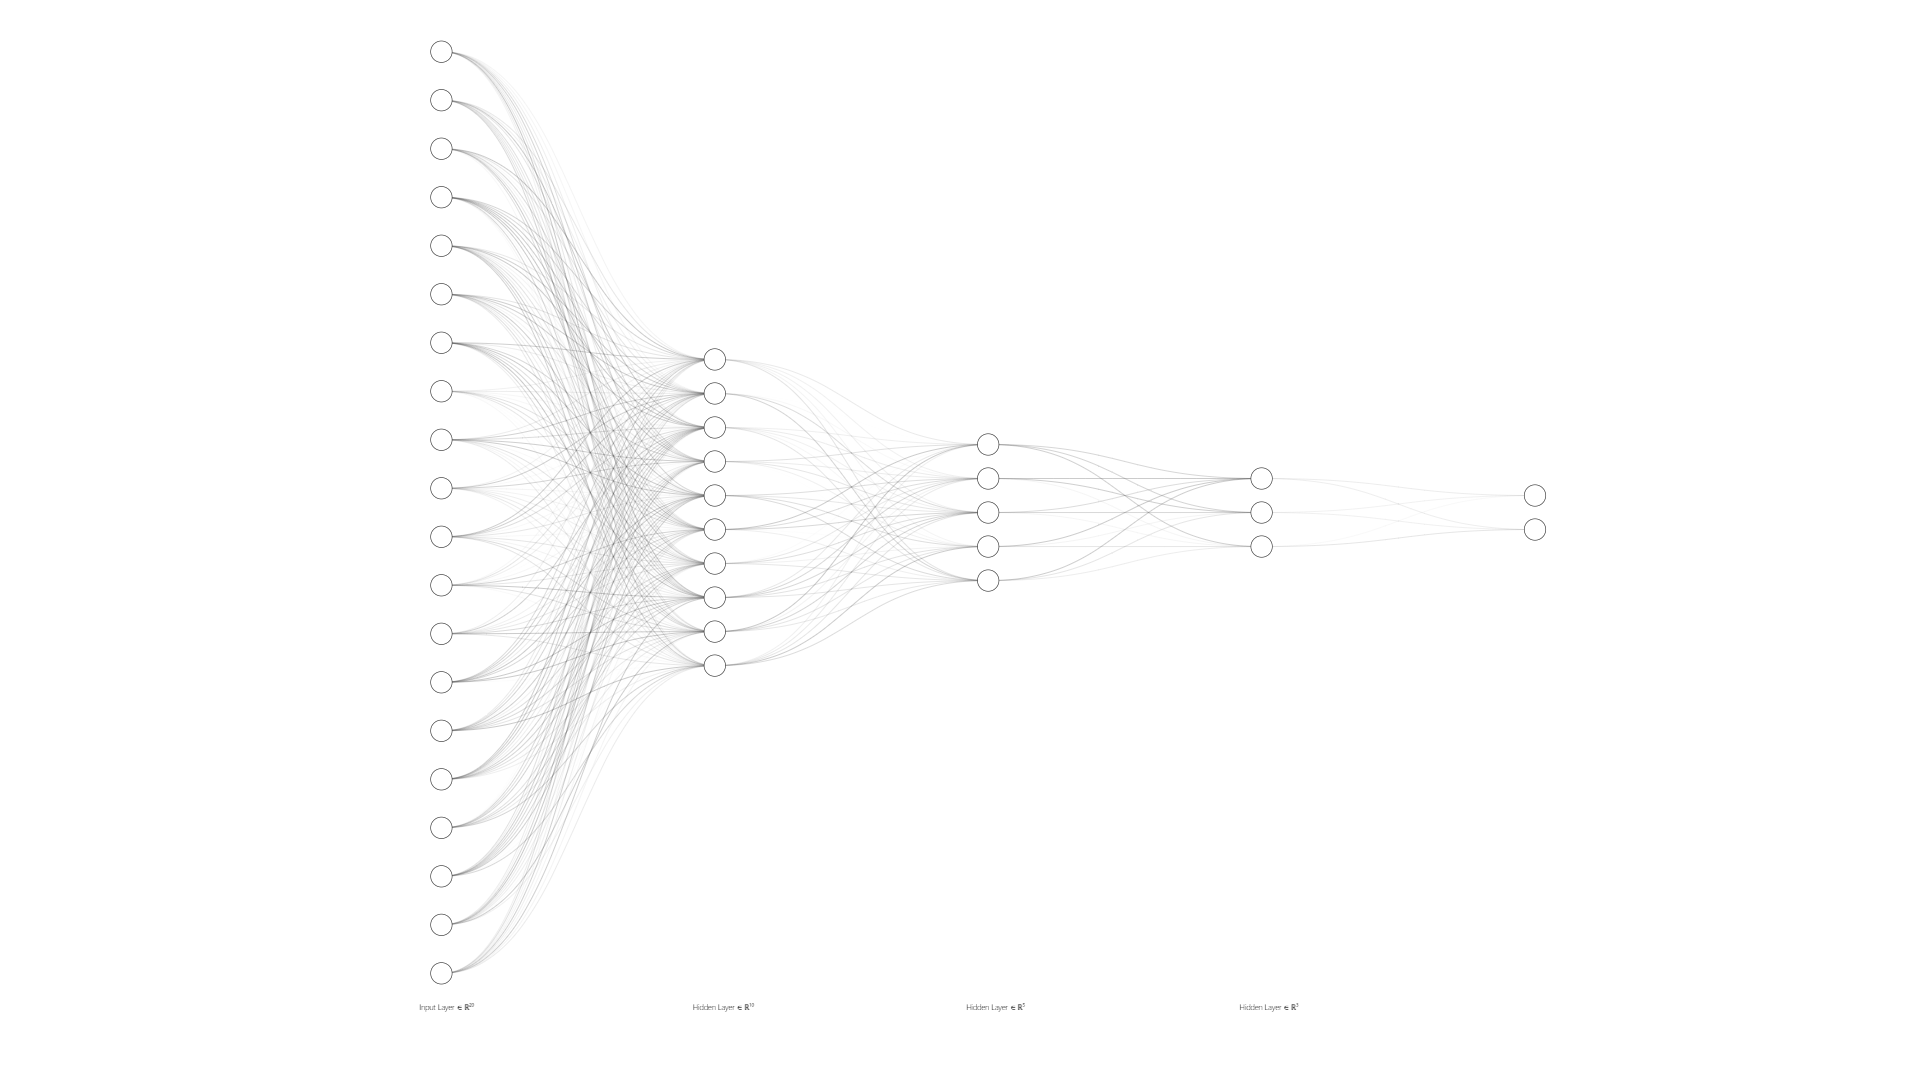

In [4]:
mlp_clf = MLPClassifier(
      hidden_layer_sizes=[10, 5, 3],
    max_iter=500,
    activation='identity',
    solver="sgd",
    alpha=0.001,
    batch_size=32,
    validation_fraction=0.2,
    learning_rate="constant",
    learning_rate_init=0.001,
    tol=0.001,
    verbose=False,
    random_state=42
)

mlp_clf.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[10, 5, ...]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'identity'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-4Tolerance for the optimization. When the loss or score is not improvingby at least ``tol`` for ``n_iter_no_change`` consecutive iterations,unless ``learning_rate`` is set to 'adaptive', convergence isconsidered to be reached and training stops.",0.001
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.2
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [5]:
y_pred = mlp_clf.predict(X_test)
y_pred

array([1, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 0, 2, 0, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 0, 0, 1, 0, 2, 1, 2, 0, 1, 2, 0, 0, 2, 2, 2,
       0, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 1, 2, 2, 0, 1, 2, 0, 2, 2, 2,
       2, 1, 0, 2, 2, 1, 1, 1, 2, 2, 0, 2, 1, 0, 0, 0, 2, 0, 2, 2, 2, 1,
       1, 1, 1, 2, 0, 0, 0, 1, 2, 2, 1, 2])

In [6]:
f1_score(y_test, y_pred, average = 'weighted')

0.8117682317682318

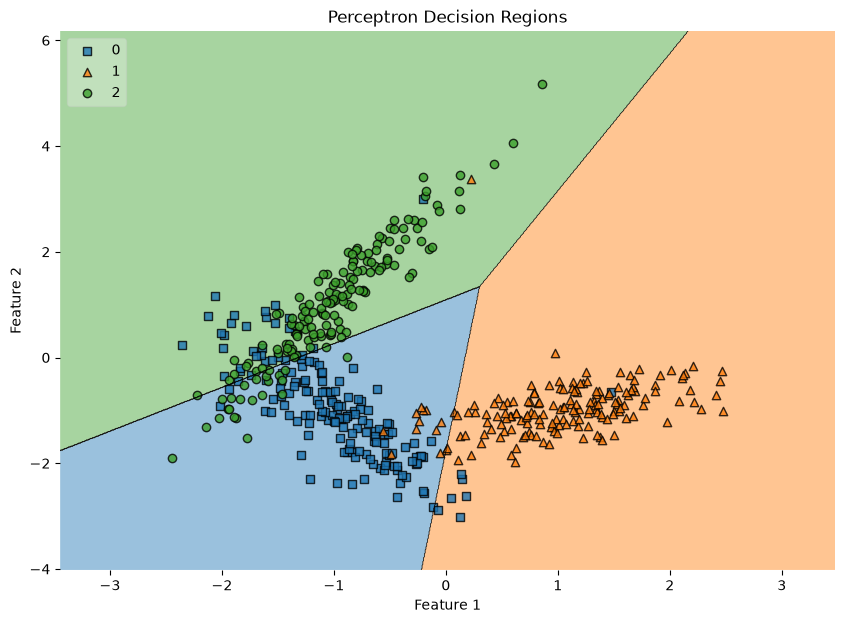

In [7]:
# !pip install mlxtend==0.23.1
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize = (10, 7))
plot_decision_regions(X, y, clf = mlp_clf, legend = 2)
plt.title('Perceptron Decision Regions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<u>Observation</u> : "Without an activation function, a dense neural network collapses into a simple linear model. Activation functions are therefore essential to introduce the non-linearity required for the network to learn complex patterns."

In [8]:
mlp_clf_activated = MLPClassifier(
    hidden_layer_sizes=[10, 5, 3],
    max_iter=500,
    activation='relu',
    solver="sgd",
    alpha=0.001,
    batch_size=32,
    validation_fraction=0.2,
    learning_rate="constant",
    learning_rate_init=0.001,
    tol=0.001,
    verbose=False,
    random_state=42
)

mlp_clf_activated.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[10, 5, ...]"
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-4Tolerance for the optimization. When the loss or score is not improvingby at least ``tol`` for ``n_iter_no_change`` consecutive iterations,unless ``learning_rate`` is set to 'adaptive', convergence isconsidered to be reached and training stops.",0.001
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.2
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


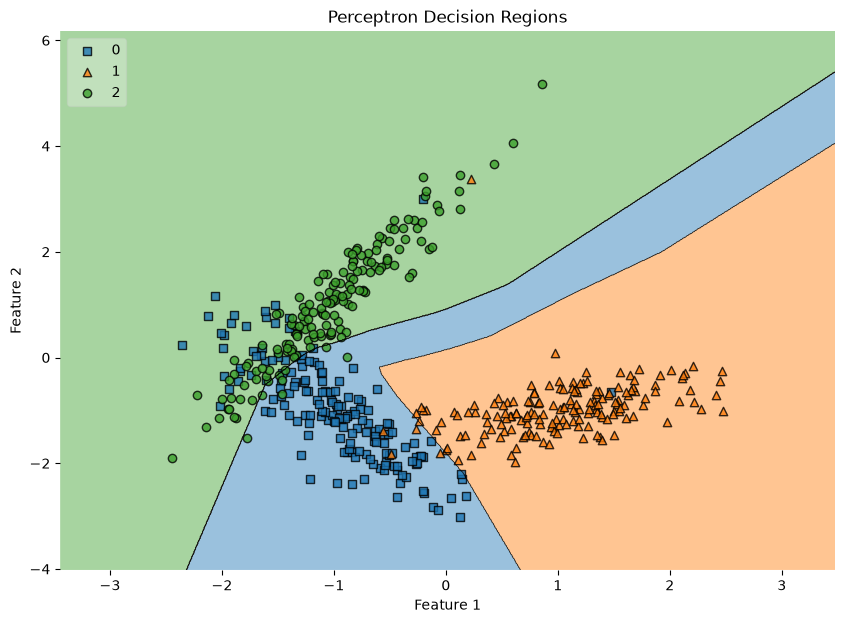

In [9]:
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize = (10, 7))
plot_decision_regions(X, y, clf = mlp_clf_activated, legend = 2)
plt.title('Perceptron Decision Regions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

---

In [ ]:
# Backpropagation for classification from first principle using NumPy / Torch
import torch
torch.manual_seed(42)

def neural_network() -> dict:
    hidden_weight: torch.Tensor = torch.randn(size=(2, 3))
    hidden_bias: torch.Tensor = torch.randn(size=(2, 1))

    output_weight: torch.Tensor = torch.randn(size=(1, 2))
    output_bias: torch.Tensor = torch.randn(size=(1, 1))

    return {
        "hidden_weight": hidden_weight, 
        "output_weight": output_weight, 
        "hidden_bias": hidden_bias, 
        "output_bias": output_bias
    }

In [24]:
def forward_propogation(X_train: torch.Tensor, parameters: dict) -> dict:
    hidden_output: torch.Tensor = torch.matmul(X_train, parameters["hidden_weight"].T) + parameters["hidden_bias"].T
    # hidden_activation: torch.Tensor = torch.tanh(hidden_output) # shape - (n, 2)
    hidden_activation: torch.Tensor = torch.sigmoid(hidden_output) # shape - (n, 2)

    output: torch.Tensor = torch.matmul(hidden_activation, parameters["output_weight"].T) + parameters["output_bias"].T
    output_activation: torch.Tensor = torch.sigmoid(output) # shape - (n, 1)

    return {
        "hidden_output": hidden_output, 
        "hidden_activation": hidden_activation, 
        "output": output, 
        "output_activation": output_activation
    }

In [ ]:
def backward_propagation(X_train: torch.Tensor, y_train: torch.Tensor, y_hat: dict, parameters: dict) -> None:
    # Gradient Calculation
    dz2 = y_hat["output_activation"] - y_train # shape (n, 1)
    output_weight_gradient: torch.Tensor = dz2.T @ y_hat["hidden_activation"] / X_train.shape[0]
    output_bias_gradient: torch.Tensor= torch.sum(dz2, dim=0, keepdim=True)

    da1 = dz2 @ parameters["output_weight"] # shape (n, 2)
    # dz1 = da1 * (1 - torch.tanh(y_hat["hidden_output"]) ** 2) # shape (n, 2) —→ Tanh activation gradient
    dz1 = da1 * (y_hat["hidden_output"] * (1 - y_hat["hidden_output"])) # shape (n, 2)
    hidden_weight_gradient = dz1.T @ X_train / X_train.shape[0]
    hidden_bias_gradient = torch.sum(dz1.T, dim=1, keepdim=True) / X_train.shape[0]

    # Parameters Updation
    parameters["hidden_weight"] -= 0.001 * hidden_weight_gradient
    parameters["hidden_bias"] -= 0.001 * hidden_bias_gradient

    parameters["output_weight"] -= 0.001 * output_weight_gradient
    parameters["output_bias"] -= 0.001 * output_bias_gradient

In [ ]:
from sklearn.datasets import make_classification

def main():
    # Dummy Classification dataset
    X, y = make_classification(
        n_samples = 500,
        n_features = 3,
        n_informative = 1,
        n_redundant = 0,
        n_classes = 2,
        n_clusters_per_class = 1,
        class_sep = 0.5,
        random_state = 42
    )

    # Converting to torch tensors
    X: torch.Tensor = torch.from_numpy(X).to(torch.float32)
    y: torch.Tensor = torch.from_numpy(y).reshape(-1, 1).to(torch.float32)

    # Initializing the neural network
    parameters = neural_network()

    for i in range(10):
        # Forward Propagation
        y_hat = forward_propogation(X, parameters)

        # Loss Calculation
        epsilon = 1e-15  # For numerical stability —→ So the value of activation will not become either 0 or 1
        y_hat_clipped = torch.clamp(y_hat["output_activation"], epsilon, 1 - epsilon)
        loss = -torch.mean(
            y * torch.log(y_hat_clipped) + 
            (1 - y) * torch.log(1 - y_hat_clipped)
        )
        print(f"Loss at {i}th epoch:", loss.item())

        # Backward Propagation
        backward_propagation(X, y, y_hat, parameters)

main()

Loss at 0th epoch: 0.8302168250083923
Loss at 1th epoch: 0.8018897175788879
Loss at 2th epoch: 0.7789638638496399
Loss at 3th epoch: 0.7606110572814941
Loss at 4th epoch: 0.7460538744926453
Loss at 5th epoch: 0.7345948815345764
Loss at 6th epoch: 0.7256302237510681
Loss at 7th epoch: 0.7186517715454102
Loss at 8th epoch: 0.7132408022880554
Loss at 9th epoch: 0.7090583443641663


Note → Since activation functions applied element-wise, the gradient of activation(a) wrt. raw outputs(z) gets element-wise multiplied with the overall gradient equation also the operations inside the same are also element-wise multipliee.

$dz1 = da1 * (1 - torch.tanh(y_hat[\text{hidden output}]) ^ 2)$ <br><br>
$dz1 = da1 * (y_hat[\text{hidden output}] * (1 - y_hat[\text{hidden output}]))$